#

In [ ]:
---
execute:
  eval: false
  echo: true
  warning: false
format:
  html:
    code-fold: false
---

Importing the packages.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs, make_moons, make_circles
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering

Creating distinct synthetic datasets.

In [2]:
n_samples = 300
random_state = 42

X_blobs, _ = make_blobs(n_samples=n_samples, centers=3, cluster_std=0.6, random_state=random_state)
X_moons, _ = make_moons(n_samples=n_samples, noise=0.05, random_state=random_state)
X_circles, _ = make_circles(n_samples=n_samples, factor=0.5, noise=0.05, random_state=random_state)

datasets = [
    ("Globular Data", X_blobs),
    ("Arbitrary Shapes", X_moons),
    ("Concentric Geometry", X_circles)
]

Instantiating the methods.

In [3]:
models = [
    ("k-Means", KMeans(n_clusters=3, random_state=random_state, n_init=10)),
    ("DBSCAN", DBSCAN(eps=0.2, min_samples=5)),
    ("Agglomerative (Single Linkage)", AgglomerativeClustering(n_clusters=2, linkage='single'))
]

Fitting and plotting the results.

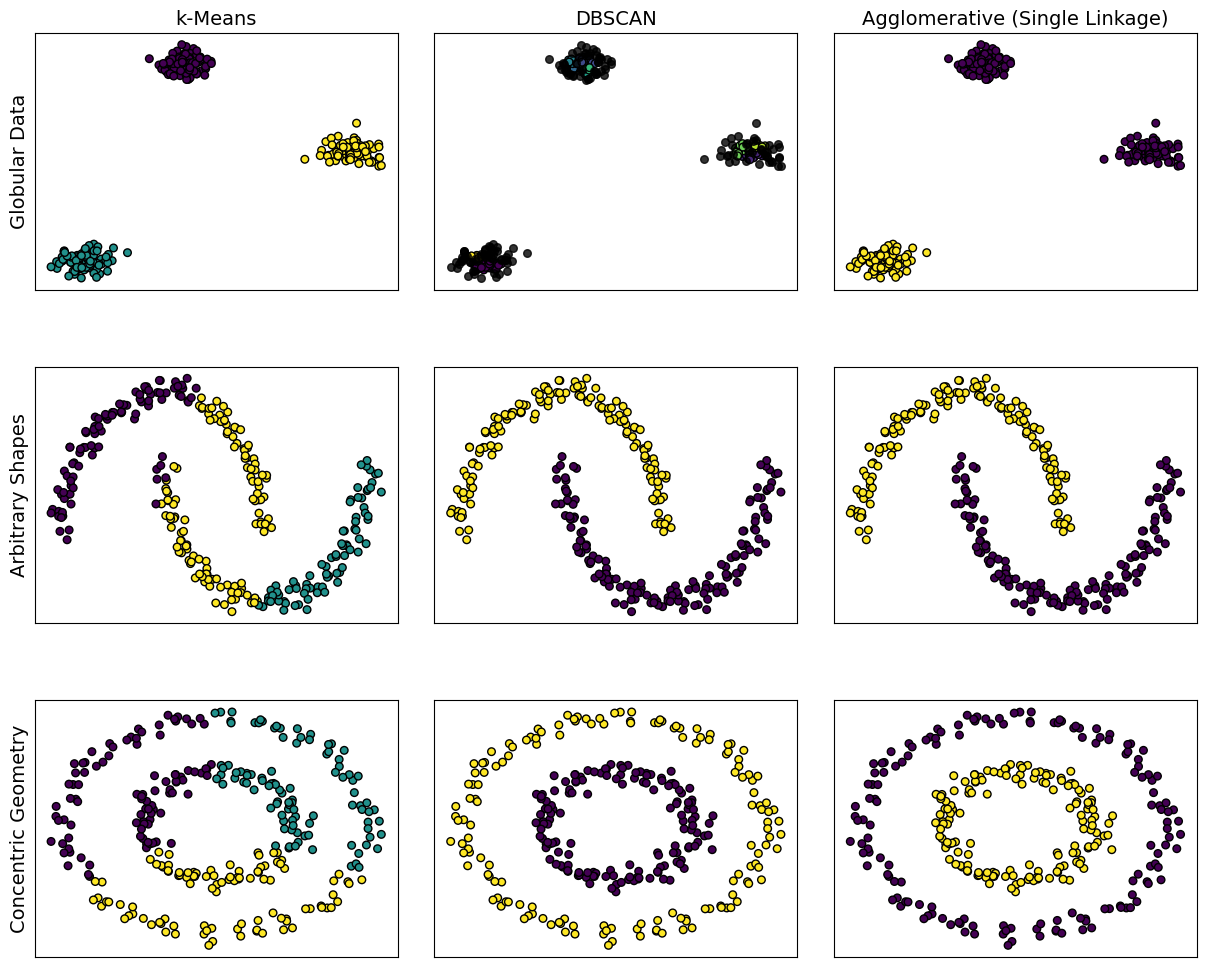

In [10]:
fig, axes = plt.subplots(len(datasets), len(models), figsize=(15, 12))
plt.subplots_adjust(hspace=0.3, wspace=0.1)

for row_idx, (data_name, X) in enumerate(datasets):
    for col_idx, (model_name, model) in enumerate(models):
        ax = axes[row_idx, col_idx]

        y_pred = model.fit_predict(X)

        clustered_mask = y_pred != -1
        ax.scatter(X[clustered_mask, 0], X[clustered_mask, 1],
                   c=y_pred[clustered_mask], cmap='viridis',
                   s=30, edgecolor='k')

        noise_mask = y_pred == -1
        if np.any(noise_mask):
            ax.scatter(X[noise_mask, 0], X[noise_mask, 1],
                       c='black',
                       s=30, edgecolor='k', alpha=0.8)

        ax.set_xticks([])
        ax.set_yticks([])

        if row_idx == 0:
            ax.set_title(model_name, fontsize=14)

        if col_idx == 0:
            ax.set_ylabel(data_name, fontsize=14)